In [ ]:
### Regression

In [ ]:
### problem statement
# predict the GPA using SAT Score
# dependent variable is GPA while independent variable is SAT_Score

In [44]:
### install required packages
!pip install pickle4

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for pickle4: filename=pickle4-0.0.1-py2.py3-none-any.whl size=19770 sha256=b850637c8652aaff6d30ceb12d785dbfc9f08d5ffa977b7f3f4751cb5138549e
  Stored in directory: c:\users\sainya.vishwakarma\appdata\local\pip\cache\wheels\2a\98\74\c435d99d3e2c502ef12286fc0e2e3661c32cd5556cecfe5542
Successfully built pickle4



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
### load the dataset

In [5]:
df = pd.read_csv("C:\\Users\\sainya.vishwakarma\\Python\\ML2\\SAT_scores.csv")
df

,SAT Score,GPA
0,1600,4.0
1,1593,4.0
2,1587,4.0
3,1580,4.0
4,1573,4.0
...,...,...
176,427,0.0
177,420,0.0
178,413,0.0
179,407,0.0


In [ ]:
### elaboratory data analysis

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SAT Score  181 non-null    int64  
 1   GPA        181 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 3.0 KB


In [ ]:
### get statistical info of data

In [7]:
df.describe()

,SAT Score,GPA
count,181.000000,181.000000
mean,1000.000000,2.617901
std,349.293573,1.559243
min,400.000000,0.000000
25%,700.000000,1.390000
50%,1000.000000,3.370000
75%,1300.000000,3.970000
max,1600.000000,4.000000


In [15]:
### check if dataset have any missing values

In [16]:
df.isna().sum()

SAT Score    0
GPA          0
dtype: int64

C:\Users\sainya.vishwakarma\AppData\Local\Temp\ipykernel_26592\2691087600.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


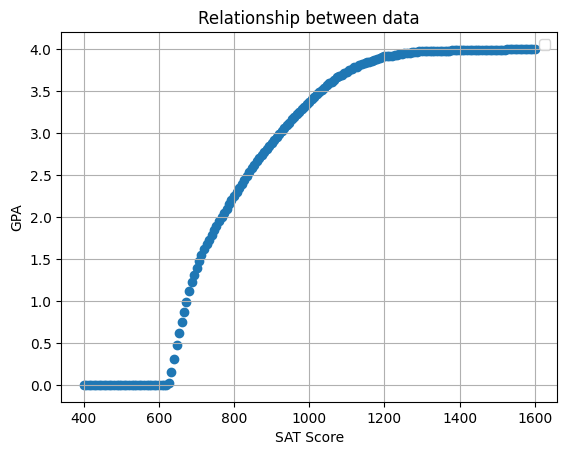

In [17]:
### visualization of data
plt.scatter(df['SAT Score'],df['GPA'])
plt.xlabel('SAT Score')
plt.ylabel('GPA')
plt.title('Relationship between data')
plt.grid()

In [18]:
# correlation analysis
df.corr()

,SAT Score,GPA
SAT Score,1.000000,0.923073
GPA,0.923073,1.000000


In [ ]:
### split the data into x and y

In [21]:
x = df.drop(['GPA'], axis = 1)
y = df['GPA']

In [ ]:
### split the data into training and test set

In [24]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size = 0.8,random_state=2)

In [26]:
### train the model

In [27]:
from sklearn.linear_model import LinearRegression

#create the model
model = LinearRegression()

# fit the model

model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['SAT Score']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.436
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [ ]:
### model evaluation using training dataset

In [32]:
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,mean_squared_error,root_mean_squared_error,r2_score

# predict the y values for train data
y_pred = model.predict(x_train)

mae = mean_absolute_error(y_train,y_pred)
mape = mean_absolute_percentage_error(y_train,y_pred)
mse = mean_squared_error(y_train,y_pred)
rmse = root_mean_squared_error(y_train,y_pred)
r2s = r2_score(y_train,y_pred)

print(f"mean absolute error : {mae:.2f}")
print(f"mean absolute percentage error : {mape:.2f}")
print(f"mean squared error : {mse:.2f}")
print(f"root mean squared error : {rmse:.2f}")
print(f"r2 score : {r2s:.2f}")

mean absolute error : 0.52
mean absolute percentage error : 425597564773198.38
mean squared error : 0.34
root mean squared error : 0.58
r2 score : 0.84


In [ ]:
### model evaluation using testing datasets

In [33]:
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,mean_squared_error,root_mean_squared_error,r2_score

# predict the y values for test data
y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test,y_pred)
mape = mean_absolute_percentage_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2s = r2_score(y_test,y_pred)

print(f"mean absolute error : {mae:.2f}")
print(f"mean absolute percentage error : {mape:.2f}")
print(f"mean squared error : {mse:.2f}")
print(f"root mean squared error : {rmse:.2f}")
print(f"r2 score : {r2s:.2f}")

mean absolute error : 0.60
mean absolute percentage error : 1125587716594690.00
mean squared error : 0.46
root mean squared error : 0.68
r2 score : 0.86


In [ ]:
### train result visualization

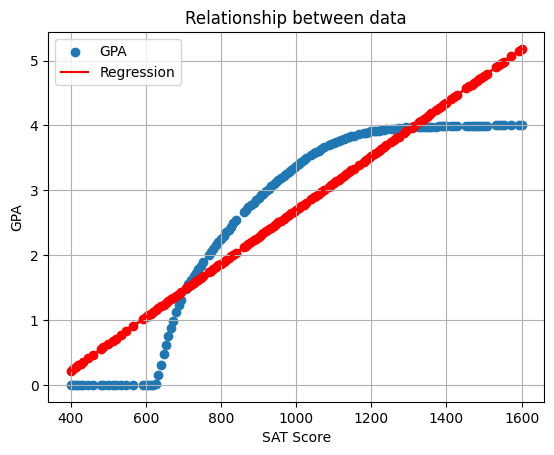

In [39]:
# predict the train data

y_pred = model.predict(x_train)

# plot the test data
plt.scatter(x_train['SAT Score'],y_train,label='GPA')

#plot the regression line
plt.scatter(x_train['SAT Score'],y_pred,color='Red')
plt.plot(x_train['SAT Score'],y_pred,color='Red',label='Regression')

plt.xlabel('SAT Score')
plt.ylabel('GPA')
plt.title('Relationship between data')
plt.grid()
plt.legend()

In [ ]:
### test result visualization

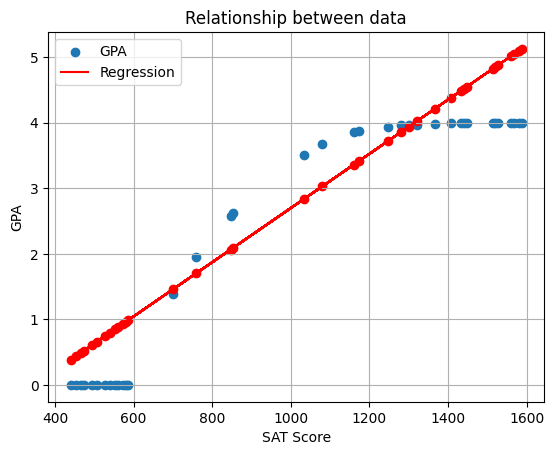

In [38]:
# predict the test data

y_pred = model.predict(x_test)

# plot the test data
plt.scatter(x_test['SAT Score'],y_test,label='GPA')

#plot the regression line
plt.scatter(x_test['SAT Score'],y_pred,color='Red')
plt.plot(x_test['SAT Score'],y_pred,color='Red',label='Regression')

plt.xlabel('SAT Score')
plt.ylabel('GPA')
plt.title('Relationship between data')
plt.grid()
plt.legend()

In [46]:
import pickle

# open a file

with open("model.pkl","wb") as file:
    pickle.dump(model,file)